# Restaurant Market Segmentation & Opportunity Analysis

In [1]:
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('../dataset/city_scores_v2.csv')
df.head()

,city,state,restaurant_count,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score
0,Edmonton,AB,1550,3.512258,48241,31.123226,0.095253,0.431903,0.597200,-0.201384
1,Sherwood Park,AB,107,3.593458,2058,19.233645,0.001787,0.016412,0.678264,-0.139683
2,Tucson,AZ,1643,3.460134,192649,117.254413,0.387510,0.458681,0.545162,-0.052882
3,Oro Valley,AZ,62,3.500000,7336,118.322581,0.012469,0.003455,0.584962,-0.111795
4,Carpinteria,CA,58,3.853448,9114,157.137931,0.016067,0.002303,0.937822,-0.180222


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   city                       118 non-null    str    
 1   state                      118 non-null    str    
 2   restaurant_count           118 non-null    int64  
 3   avg_rating                 118 non-null    float64
 4   total_reviews              118 non-null    int64  
 5   avg_review_per_restaurant  118 non-null    float64
 6   norm_demand                118 non-null    float64
 7   norm_competition           118 non-null    float64
 8   norm_rating                118 non-null    float64
 9   opportunity_score          118 non-null    float64
dtypes: float64(6), int64(2), str(2)
memory usage: 9.3 KB


In [4]:
df.describe()

,restaurant_count,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score
count,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000,118.000000
mean,238.635593,3.466109,27120.152542,82.425868,0.052508,0.054315,0.551128,-0.100266
std,481.159118,0.197980,70406.135249,48.417119,0.142490,0.138543,0.197651,0.046427
min,50.000000,2.914063,1175.000000,19.233645,0.000000,0.000000,0.000000,-0.201384
25%,63.000000,3.324772,3962.250000,50.495238,0.005641,0.003743,0.410025,-0.136299
50%,85.500000,3.471688,5955.500000,70.534371,0.009675,0.010222,0.556697,-0.103168
75%,143.500000,3.617706,12876.500000,98.072061,0.023682,0.026922,0.702472,-0.072221
max,3523.000000,3.915730,495289.000000,294.296296,1.000000,1.000000,1.000000,0.104344


### Rebuild Opportunity Score

In [5]:
# Normalize the features using Min-Max Scaling
scaler = MinMaxScaler()
df[['norm_demand', 'norm_competition', 'norm_rating']] = scaler.fit_transform(df[['total_reviews', 'restaurant_count', 'avg_rating']])

In [6]:
# Create new score
df['opportunity_score_v3'] = (df['norm_demand'] * 0.5) - (df['norm_competition'] * 0.3) - (df['norm_rating'] * 0.2)

In [7]:
# Find the top 10 cities based on the new opportunity score
df.sort_values(by='opportunity_score_v3', ascending=False).head(10)

,city,state,restaurant_count,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score,opportunity_score_v3
48,New Orleans,LA,1390,3.765108,386603,278.131655,0.780039,0.385834,0.849628,0.104344,0.104344
89,Philadelphia,PA,3523,3.584871,495289,140.587284,1.000000,1.000000,0.669691,0.066062,0.066062
109,Madison,TN,64,2.914063,2424,37.875000,0.002528,0.004031,0.000000,0.000055,0.000055
117,Nashville,TN,1680,3.570833,260828,155.254762,0.525492,0.469335,0.655677,-0.009190,-0.009190
55,Florissant,MO,127,3.059055,4021,31.661417,0.005760,0.022171,0.144751,-0.032722,-0.032722
58,Arnold,MO,74,3.094595,2597,35.094595,0.002878,0.006910,0.180231,-0.036680,-0.036680
36,Collinsville,IL,58,3.103448,2072,35.724138,0.001815,0.002303,0.189070,-0.037597,-0.037597
45,Plainfield,IN,86,3.104651,4499,52.313953,0.006727,0.010366,0.190271,-0.037800,-0.037800
57,Fenton,MO,67,3.104478,2630,39.253731,0.002945,0.004895,0.190098,-0.038016,-0.038016
113,Antioch,TN,75,3.133333,4414,58.853333,0.006555,0.007198,0.218906,-0.042663,-0.042663


### Clustering

In [8]:
features = df[['total_reviews', 'restaurant_count', 'avg_rating']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

In [9]:
df.groupby('cluster')['opportunity_score_v3'].mean().sort_values(ascending=False)

cluster
2    0.085203
0   -0.063019
1   -0.106061
Name: opportunity_score_v3, dtype: float64

**Cluster 2 - Best opportunity:** Highest score

- Underserved markets
- Good demand + lower competition

**Cluster 0 - Moderate / risky:** Slightly negative

- High demand but high competition

**Cluster 1 - Worst opportunity:** Lowest score

- Low demand or strong competition

In [10]:
df[['city', 'cluster']].sort_values(by='cluster', ascending=False)

,city,cluster
48,New Orleans,2
89,Philadelphia,2
3,Oro Valley,1
4,Carpinteria,1
7,Newark,1
...,...,...
21,Tampa,0
44,Indianapolis,0
59,Saint Louis,0
74,Reno,0


In [11]:
for c in df['cluster'].unique():
    print(f"\nCluster {c}:")
    print(df[df['cluster'] == c]['city'].values)


Cluster 1:
<StringArray>
[      'Edmonton',  'Sherwood Park',     'Oro Valley',    'Carpinteria',
         'Goleta',         'Newark',     'Wilmington',     'New Castle',
        'Dunedin',     'Clearwater',
 ...
       'Gallatin',      'Hermitage',        'Madison', 'Goodlettsville',
      'Brentwood',   'Mount Juliet',        'Antioch',       'Franklin',
         'Smyrna', 'Hendersonville']
Length: 109, dtype: str

Cluster 0:
<StringArray>
[       'Tucson', 'Santa Barbara',         'Tampa',  'Indianapolis',
   'Saint Louis',          'Reno',     'Nashville']
Length: 7, dtype: str

Cluster 2:
<StringArray>
['New Orleans', 'Philadelphia']
Length: 2, dtype: str


### Visualize

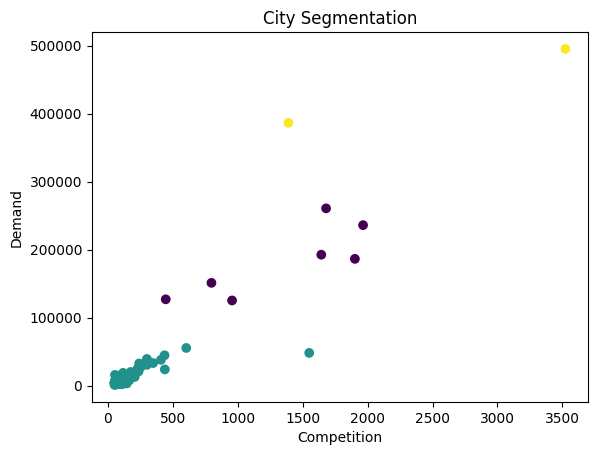

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df['restaurant_count'], df['total_reviews'], c=df['cluster'])
plt.xlabel("Competition")
plt.ylabel("Demand")
plt.title("City Segmentation")
plt.show()

**🥇Cluster 2 (New Orleans, Philadelphia)**
- Very high demand + very high competition
- Top-right of the chart

***Insight:*** These are major food markets

***Pros:*** Huge customer base

***Cons:*** 
- Extremely crowded
- Hard to stand out

***Recommendation:***
- Enter only if you have a strong unique concept or brand
- Not ideal for beginners

**🥇Cluster 0 (Tucson, Tampa, Nashville, etc.)**
- High demand + moderate competition

***Insight:*** These are balanced, attractive markets

***Pros:*** 
- Good demand
- Competition is manageable

***Cons:*** Still requires differentiation

***Recommendation:***
- Best practical target
- Look for niches (cuisine gaps, price segments)

***🚫 Cluster 1 (109 cities)***
- Low demand + low competition
- Bottom-left cluster

***Insight:*** These are small or weak markets

***Pros:*** Easy to enter

***Cons:*** Not enough customers

***Recommendation:***

Avoid unless:
- low-cost business model or very specific local opportunity

In [13]:
df[df['cluster'] == 0].sort_values(by='opportunity_score_v3', ascending=False).head(5)

,city,state,restaurant_count,avg_rating,total_reviews,avg_review_per_restaurant,norm_demand,norm_competition,norm_rating,opportunity_score,opportunity_score_v3,cluster
117,Nashville,TN,1680,3.570833,260828,155.254762,0.525492,0.469335,0.655677,-0.009190,-0.009190,0
74,Reno,NV,797,3.583438,151258,189.784191,0.303742,0.215088,0.668261,-0.046308,-0.046308,0
2,Tucson,AZ,1643,3.460134,192649,117.254413,0.387510,0.458681,0.545162,-0.052882,-0.052882,0
59,Saint Louis,MO,956,3.501569,125409,131.180962,0.251428,0.260870,0.586528,-0.069853,-0.069853,0
21,Tampa,FL,1965,3.626972,236140,120.173028,0.475528,0.551396,0.711722,-0.069999,-0.069999,0


Those 5 cities where customers exist, but the market isn’t overcrowded

In [ ]:
# Another try with 'cuisine'

cuisine_df = pd.read_csv('../dataset/cleaned_cuisines_export.csv')

coffee = cuisine_df[cuisine_df['cuisine'].str.contains("coffee", case=False)]

coffee.groupby('city').agg({
    'review_count': 'sum',
    'stars': 'mean',
    'business_id': 'count'
}).sort_values(by='review_count', ascending=False).head(10)

,review_count,stars,business_id
city,,,
Philadelphia,67761,3.577441,594
New Orleans,38670,3.873272,217
Nashville,24729,3.694313,211
Tampa,22571,3.638000,250
Indianapolis,16692,3.389222,167
Santa Barbara,15299,3.891026,78
Tucson,15145,3.523952,167
Reno,13323,3.652778,108
Saint Louis,12760,3.868687,99
